<a href="https://colab.research.google.com/github/amit491/Mutational_order_Cell_state_manuscript/blob/main/scRNASeq/GutAtlas_gene_signatures/pb_dat_DESeq_13Apr2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In here I am trying to get the diff.-exp. list for the Paneth and EEC cell types from the "Gut" pB data.
See -
ElmDat.inspection.13Apr2026
for logic.

# Set-up

In [ ]:
!pip install scanpy decoupler pydeseq2 watermark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━

In [ ]:
# Import the pkgs
import os
import multiprocessing
import scipy as sp
import scanpy as sc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import decoupler as dc
import pickle as pickle
from google.colab import drive
# For session info
%load_ext watermark

In [ ]:
multiprocessing.cpu_count()

8

In [ ]:
os.getcwd()

'/content'

In [ ]:
drive.mount('/content/my_drive')

Mounted at /content/my_drive


In [ ]:
my_dir = "/content/my_drive/MyDrive/colab_IO/"

In [ ]:
if os.path.exists(os.path.join(my_dir,'GutAtlas.dat/')):
  print('Dir. present!')
else:
  print('Dir. not found!')
#

Dir. present!


# Load "Gut" pB

In [ ]:
# Elmentaite et al. Epi. subset dat // Raw counts // "Gut" pB
Elm_Gut_pB = sc.read_h5ad(os.path.join(my_dir,"GutAtlas.dat/Elm_Gut_pB.h5ad"))

In [ ]:
Elm_Gut_pB

AnnData object with n_obs × n_vars = 289 × 30263
    obs: 'Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X', 'predicted_doublets', 'category', 'Age_group', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types'
    layers: 'psbulk_props'

# Create count and meta-dat

In [ ]:
sp.sparse.issparse(Elm_Gut_pB.X)

False

In [ ]:
myCounts = pd.DataFrame(
    data=Elm_Gut_pB.X,
    index=Elm_Gut_pB.obs_names,
    columns=Elm_Gut_pB.var_names
)

In [ ]:
myCounts.shape

(289, 30263)

In [ ]:
myMetaDats = pd.DataFrame(
    data=Elm_Gut_pB.obs,
    index=Elm_Gut_pB.obs_names
)

In [ ]:
myMetaDats.shape

(289, 11)

In [ ]:
myMetaDats.columns

Index(['Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X',
       'predicted_doublets', 'category', 'Age_group', 'psbulk_cells',
       'psbulk_counts'],
      dtype='object')

In [ ]:
myMetaDats.dtypes

,0
Sample name,category
annotation,category
Diagnosis,category
Age,category
Gender,category
10X,category
predicted_doublets,category
category,category
Age_group,category
psbulk_cells,float64


In [ ]:
myMetaDats.annotation = myMetaDats.annotation.astype(str)

In [ ]:
myMetaDats.dtypes

,0
Sample name,category
annotation,object
Diagnosis,category
Age,category
Gender,category
10X,category
predicted_doublets,category
category,category
Age_group,category
psbulk_cells,float64


In [ ]:
myMetaDats.annotation.value_counts()

,count
annotation,
TA,32
Stem cells,30
Goblet cell,29
Enterocyte,29
BEST4+ epithelial,21
Colonocyte,17
Proximal progenitor,15
Paneth,14
Distal progenitor,11


# Append meta-dat columns for Paneth and EEC

In [ ]:
myMetaDats = myMetaDats.assign(Cell_Paneth = myMetaDats['annotation'])

In [ ]:
myMetaDats.loc[myMetaDats['Cell_Paneth'] != 'Paneth', 'Cell_Paneth'] = 'rest'

In [ ]:
myMetaDats.Cell_Paneth.value_counts()

,count
Cell_Paneth,
rest,275
Paneth,14


===

In [ ]:
myMetaDats = myMetaDats.assign(Cell_EEC = myMetaDats['annotation'])

In [ ]:
myMetaDats.loc[myMetaDats['Cell_EEC'] != 'EECs', 'Cell_EEC'] = 'rest'

In [ ]:
myMetaDats.Cell_EEC.value_counts()

,count
Cell_EEC,
rest,279
EECs,10


In [ ]:
myMetaDats.columns

Index(['Sample name', 'annotation', 'Diagnosis', 'Age', 'Gender', '10X',
       'predicted_doublets', 'category', 'Age_group', 'psbulk_cells',
       'psbulk_counts', 'Cell_Paneth', 'Cell_EEC'],
      dtype='object')

# Set-up for Dds

In [ ]:
!pip install formulaic-contrasts

In [ ]:
# Import pyDeSeq
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
# Import formulaic contrasts
from formulaic_contrasts import FormulaicContrasts

# Paneth cells

In [ ]:
design_Paneth = FormulaicContrasts(
    myMetaDats, '~ C(Cell_Paneth, contr.treatment(base="rest"))'
).design_matrix

In [ ]:
design_Paneth.head()

,Intercept,"C(Cell_Paneth, contr.treatment(base='rest'))[T.Paneth]"
A26 (386C)_BEST2+ Goblet cell,1.0,0
A30 (398B)_BEST2+ Goblet cell,1.0,0
A32 (411C)_BEST2+ Goblet cell,1.0,0
A33 (414C)_BEST2+ Goblet cell,1.0,0
A34 (417C)_BEST2+ Goblet cell,1.0,0


In [ ]:
design_Paneth.columns = ['Intercept','condition[T.Paneth]']

In [ ]:
design_Paneth.head()

,Intercept,condition[T.Paneth]
A26 (386C)_BEST2+ Goblet cell,1.0,0
A30 (398B)_BEST2+ Goblet cell,1.0,0
A32 (411C)_BEST2+ Goblet cell,1.0,0
A33 (414C)_BEST2+ Goblet cell,1.0,0
A34 (417C)_BEST2+ Goblet cell,1.0,0


In [ ]:
design_Paneth['condition[T.Paneth]'].value_counts()

,count
condition[T.Paneth],
0,275
1,14


In [ ]:
design_Paneth['Intercept'].value_counts()

,count
Intercept,
1.0,289


In [ ]:
#
inference = DefaultInference(n_cpus=8)
#
dds_Paneth = DeseqDataSet(
    counts=myCounts,
    metadata=myMetaDats,
    design= design_Paneth,
    refit_cooks=True,
    inference=inference,
)

In [ ]:
dds_Paneth.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.39 seconds.

Fitting dispersions...
... done in 12.01 seconds.

Fitting dispersion trend curve...
... done in 0.86 seconds.

Fitting MAP dispersions...
... done in 14.36 seconds.

Fitting LFCs...
... done in 16.43 seconds.

Calculating cook's distance...
... done in 0.79 seconds.

Replacing 709 outlier genes.

Fitting dispersions...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 0.48 seconds.

Fitting LFCs...
... done in 0.63 seconds.



In [ ]:
dds_Paneth.varm['LFC'].head()

,Intercept,condition[T.Paneth]
MIR1302-2HG,-1.149567,0.858748
OR4F5,-1.177281,0.861335
AL627309.1,-1.183095,1.026444
AL627309.3,-1.156950,0.839442
AL732372.1,-1.173406,0.857460


In [ ]:
ds_Paneth = DeseqStats(dds_Paneth, contrast=np.array([0, 1]), inference=inference)

In [ ]:
ds_Paneth.summary()

Running Wald tests...
... done in 2.97 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0 1]
             baseMean  log2FoldChange     lfcSE      stat    pvalue     padj
MIR1302-2HG  0.014665        1.238912  3.451333  0.358966  0.719620      NaN
OR4F5        0.000091        1.242644  6.802926  0.182663  0.855062      NaN
AL627309.1   0.160779        1.480846  0.797721  1.856346  0.063404      NaN
AL627309.3   0.009303        1.211058  4.601680  0.263177  0.792414      NaN
AL732372.1   0.000793        1.237053  6.802908  0.181842  0.855707      NaN
...               ...             ...       ...       ...       ...      ...
AC233755.2   0.019028        1.119830  4.200345  0.266604  0.789774      NaN
AC233755.1   0.119847        1.306395  2.184782  0.597952  0.549872      NaN
AC240274.1   3.890857       -0.210057  0.431692 -0.486590  0.626549  0.91186
AC213203.1   0.000000             NaN       NaN       NaN       NaN      NaN
FAM231C      0.018293        1.160972  4.099777  0.283179  0.777039      NaN

[30263 rows x 

Running Wald tests...
... done in 6.22 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0 1]
             baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
MIR1302-2HG  0.014665        1.238912  3.451333  0.329992  0.741406   NaN
OR4F5        0.000091        1.242644  6.802926  0.167964  0.866612   NaN
AL627309.1   0.160779        1.480846  0.797721  1.730989  0.083454   NaN
AL627309.3   0.009303        1.211058  4.601680  0.241446  0.809209   NaN
AL732372.1   0.000793        1.237053  6.802908  0.167142  0.867258   NaN
...               ...             ...       ...       ...       ...   ...
AC233755.2   0.019028        1.119830  4.200345  0.242797  0.808163   NaN
AC233755.1   0.119847        1.306395  2.184782  0.552181  0.580824   NaN
AC240274.1   3.890857       -0.210057  0.431692 -0.254943  0.798767   1.0
AC213203.1   0.000000             NaN       NaN       NaN       NaN   NaN
FAM231C      0.018293        1.160972  4.099777  0.258788  0.795799   NaN

[30263 rows x 6 columns]


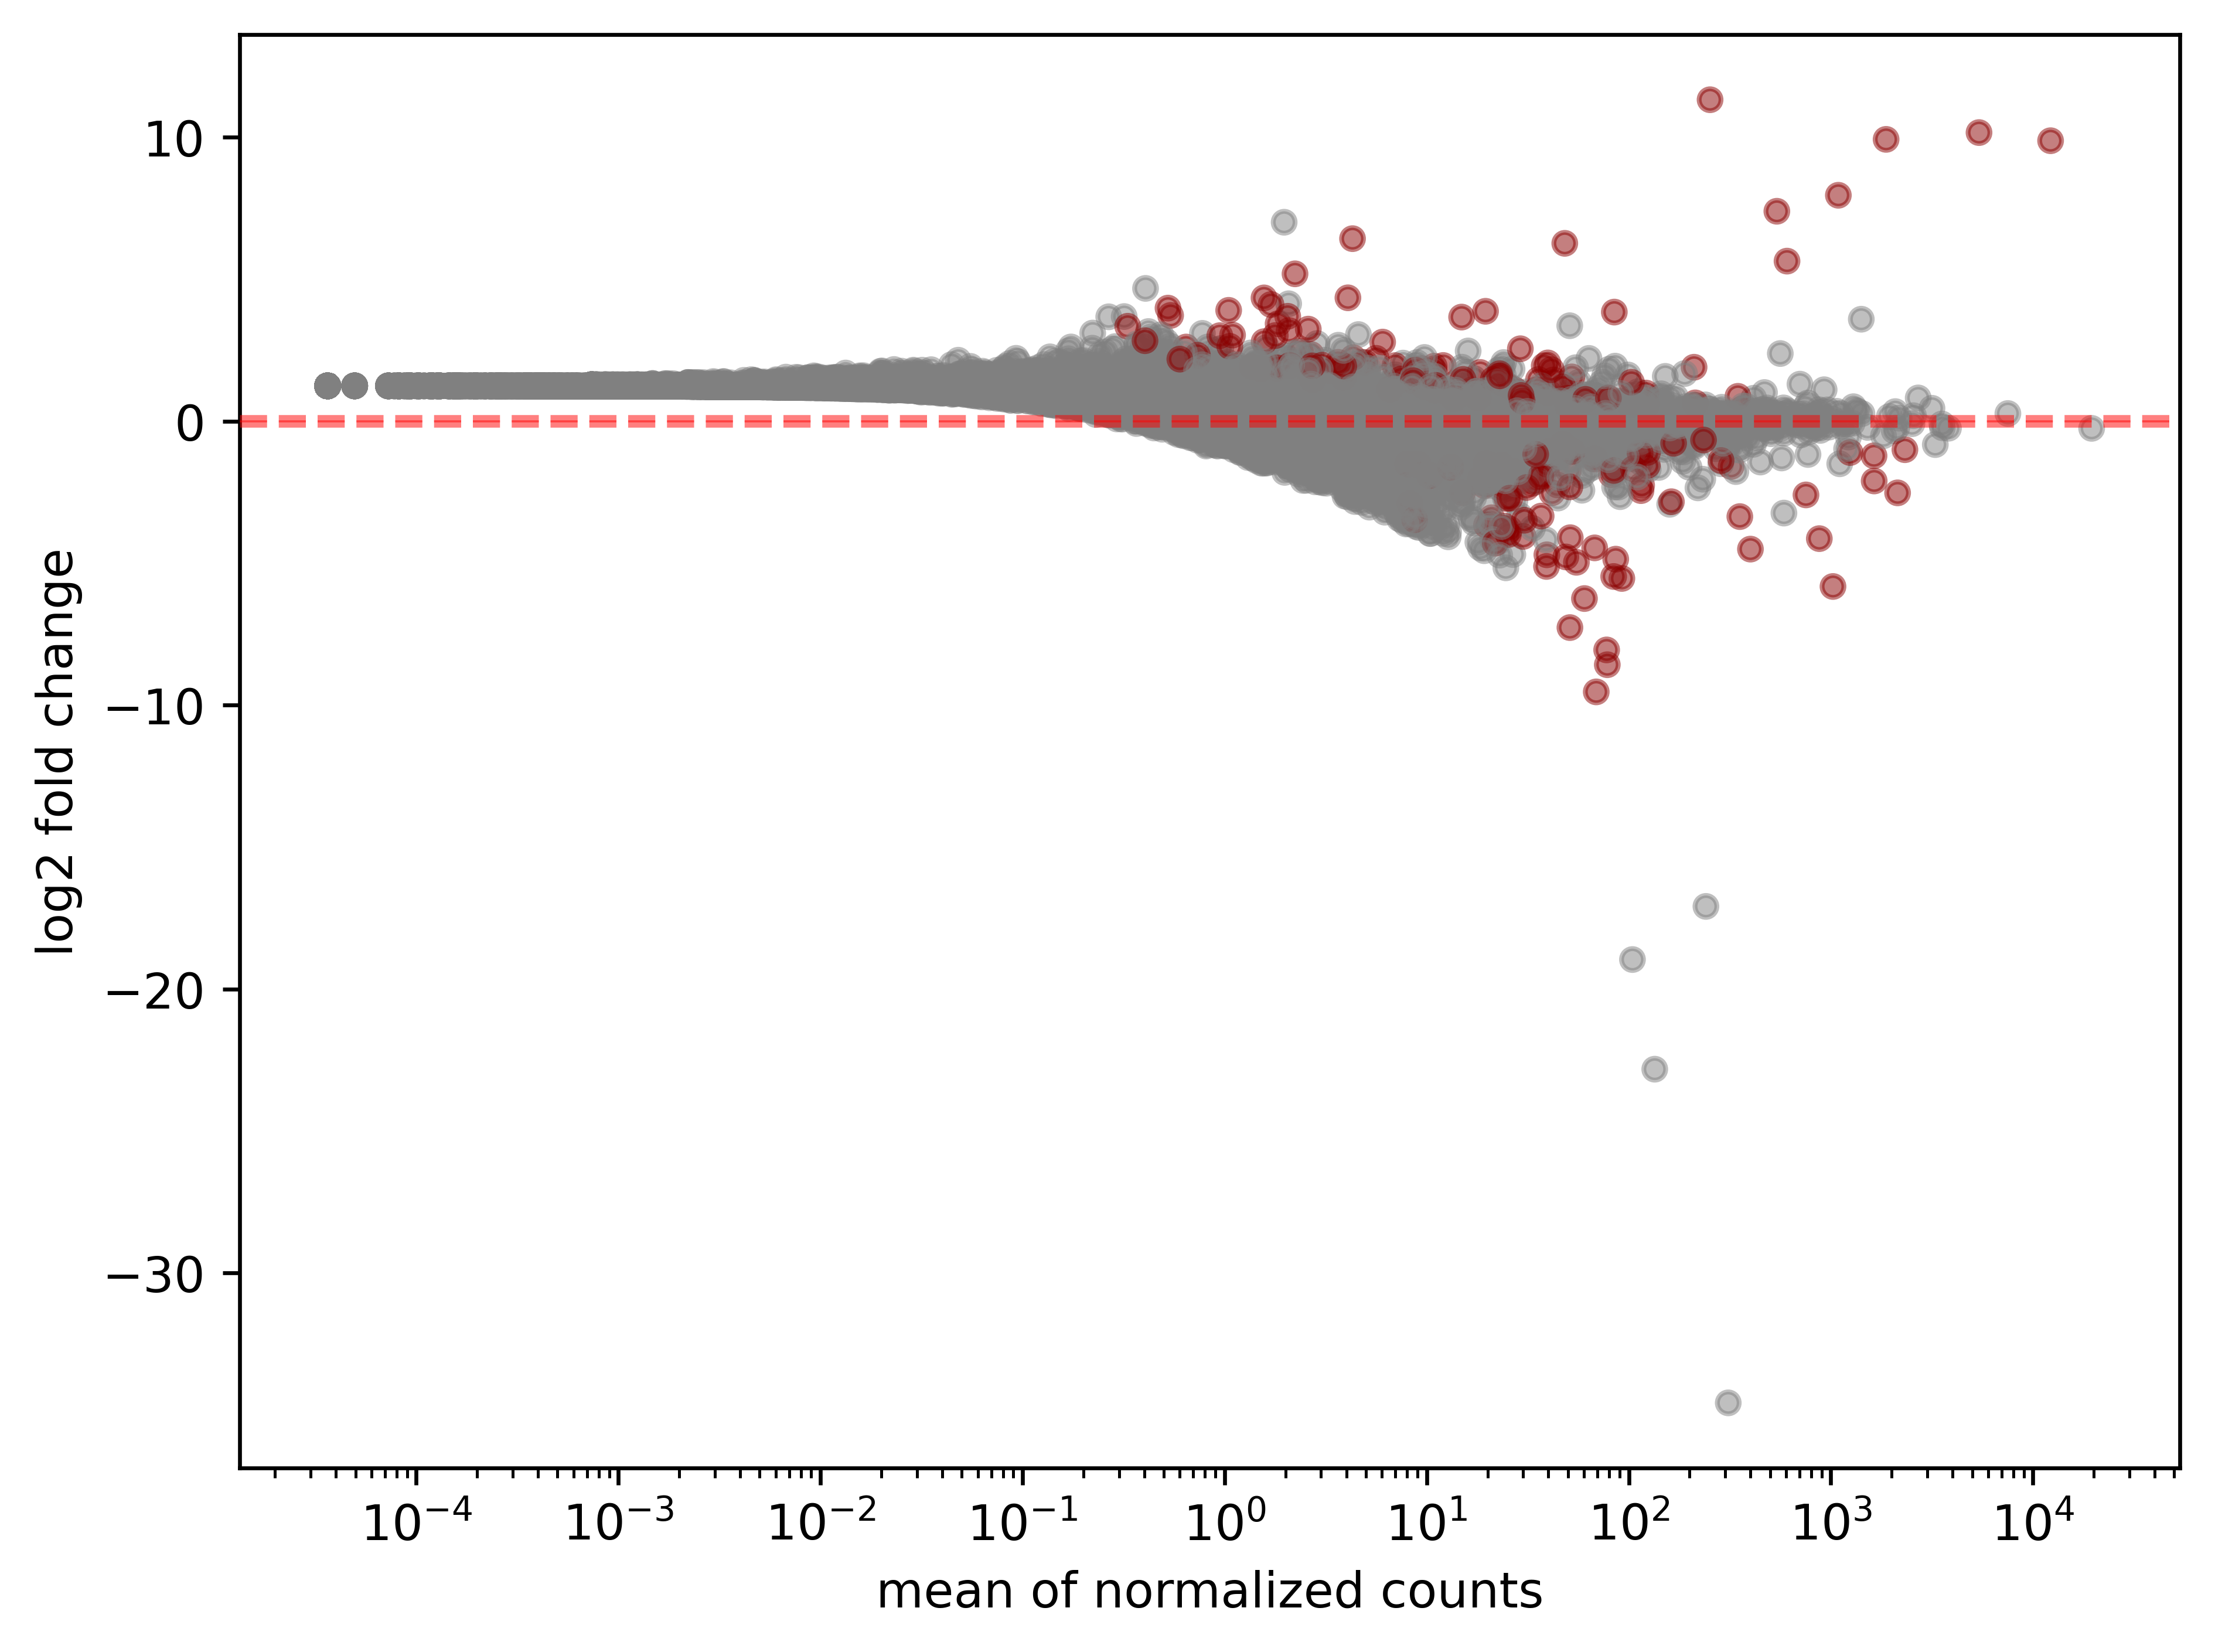

In [ ]:
ds_Paneth.summary(lfc_null=0.1, alt_hypothesis="greaterAbs")
ds_Paneth.plot_MA(s=20)

In [ ]:
ds_Paneth.lfc_shrink(coeff="condition[T.Paneth]")

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: condition[T.Paneth]
             baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
MIR1302-2HG  0.014665        0.001746  0.156627  0.329992  0.741406   NaN
OR4F5        0.000091       -0.000051  0.151165  0.167964  0.866612   NaN
AL627309.1   0.160779        0.015605  0.150705  1.730989  0.083454   NaN
AL627309.3   0.009303       -0.000526  0.150608  0.241446  0.809209   NaN
AL732372.1   0.000793       -0.000144  0.150795  0.167142  0.867258   NaN
...               ...             ...       ...       ...       ...   ...
AC233755.2   0.019028       -0.000924  0.150198  0.242797  0.808163   NaN
AC233755.1   0.119847        0.005825  0.154328  0.552181  0.580824   NaN
AC240274.1   3.890857       -0.027308  0.145157 -0.254943  0.798767   1.0
AC213203.1   0.000000             NaN       NaN       NaN       NaN   NaN
FAM231C      0.018293       -0.000860  0.150409  0.258788  0.795799   NaN

[30263 rows x 6 columns]


... done in 13.80 seconds.



In [ ]:
print(ds_Paneth.shrunk_LFCs)

True


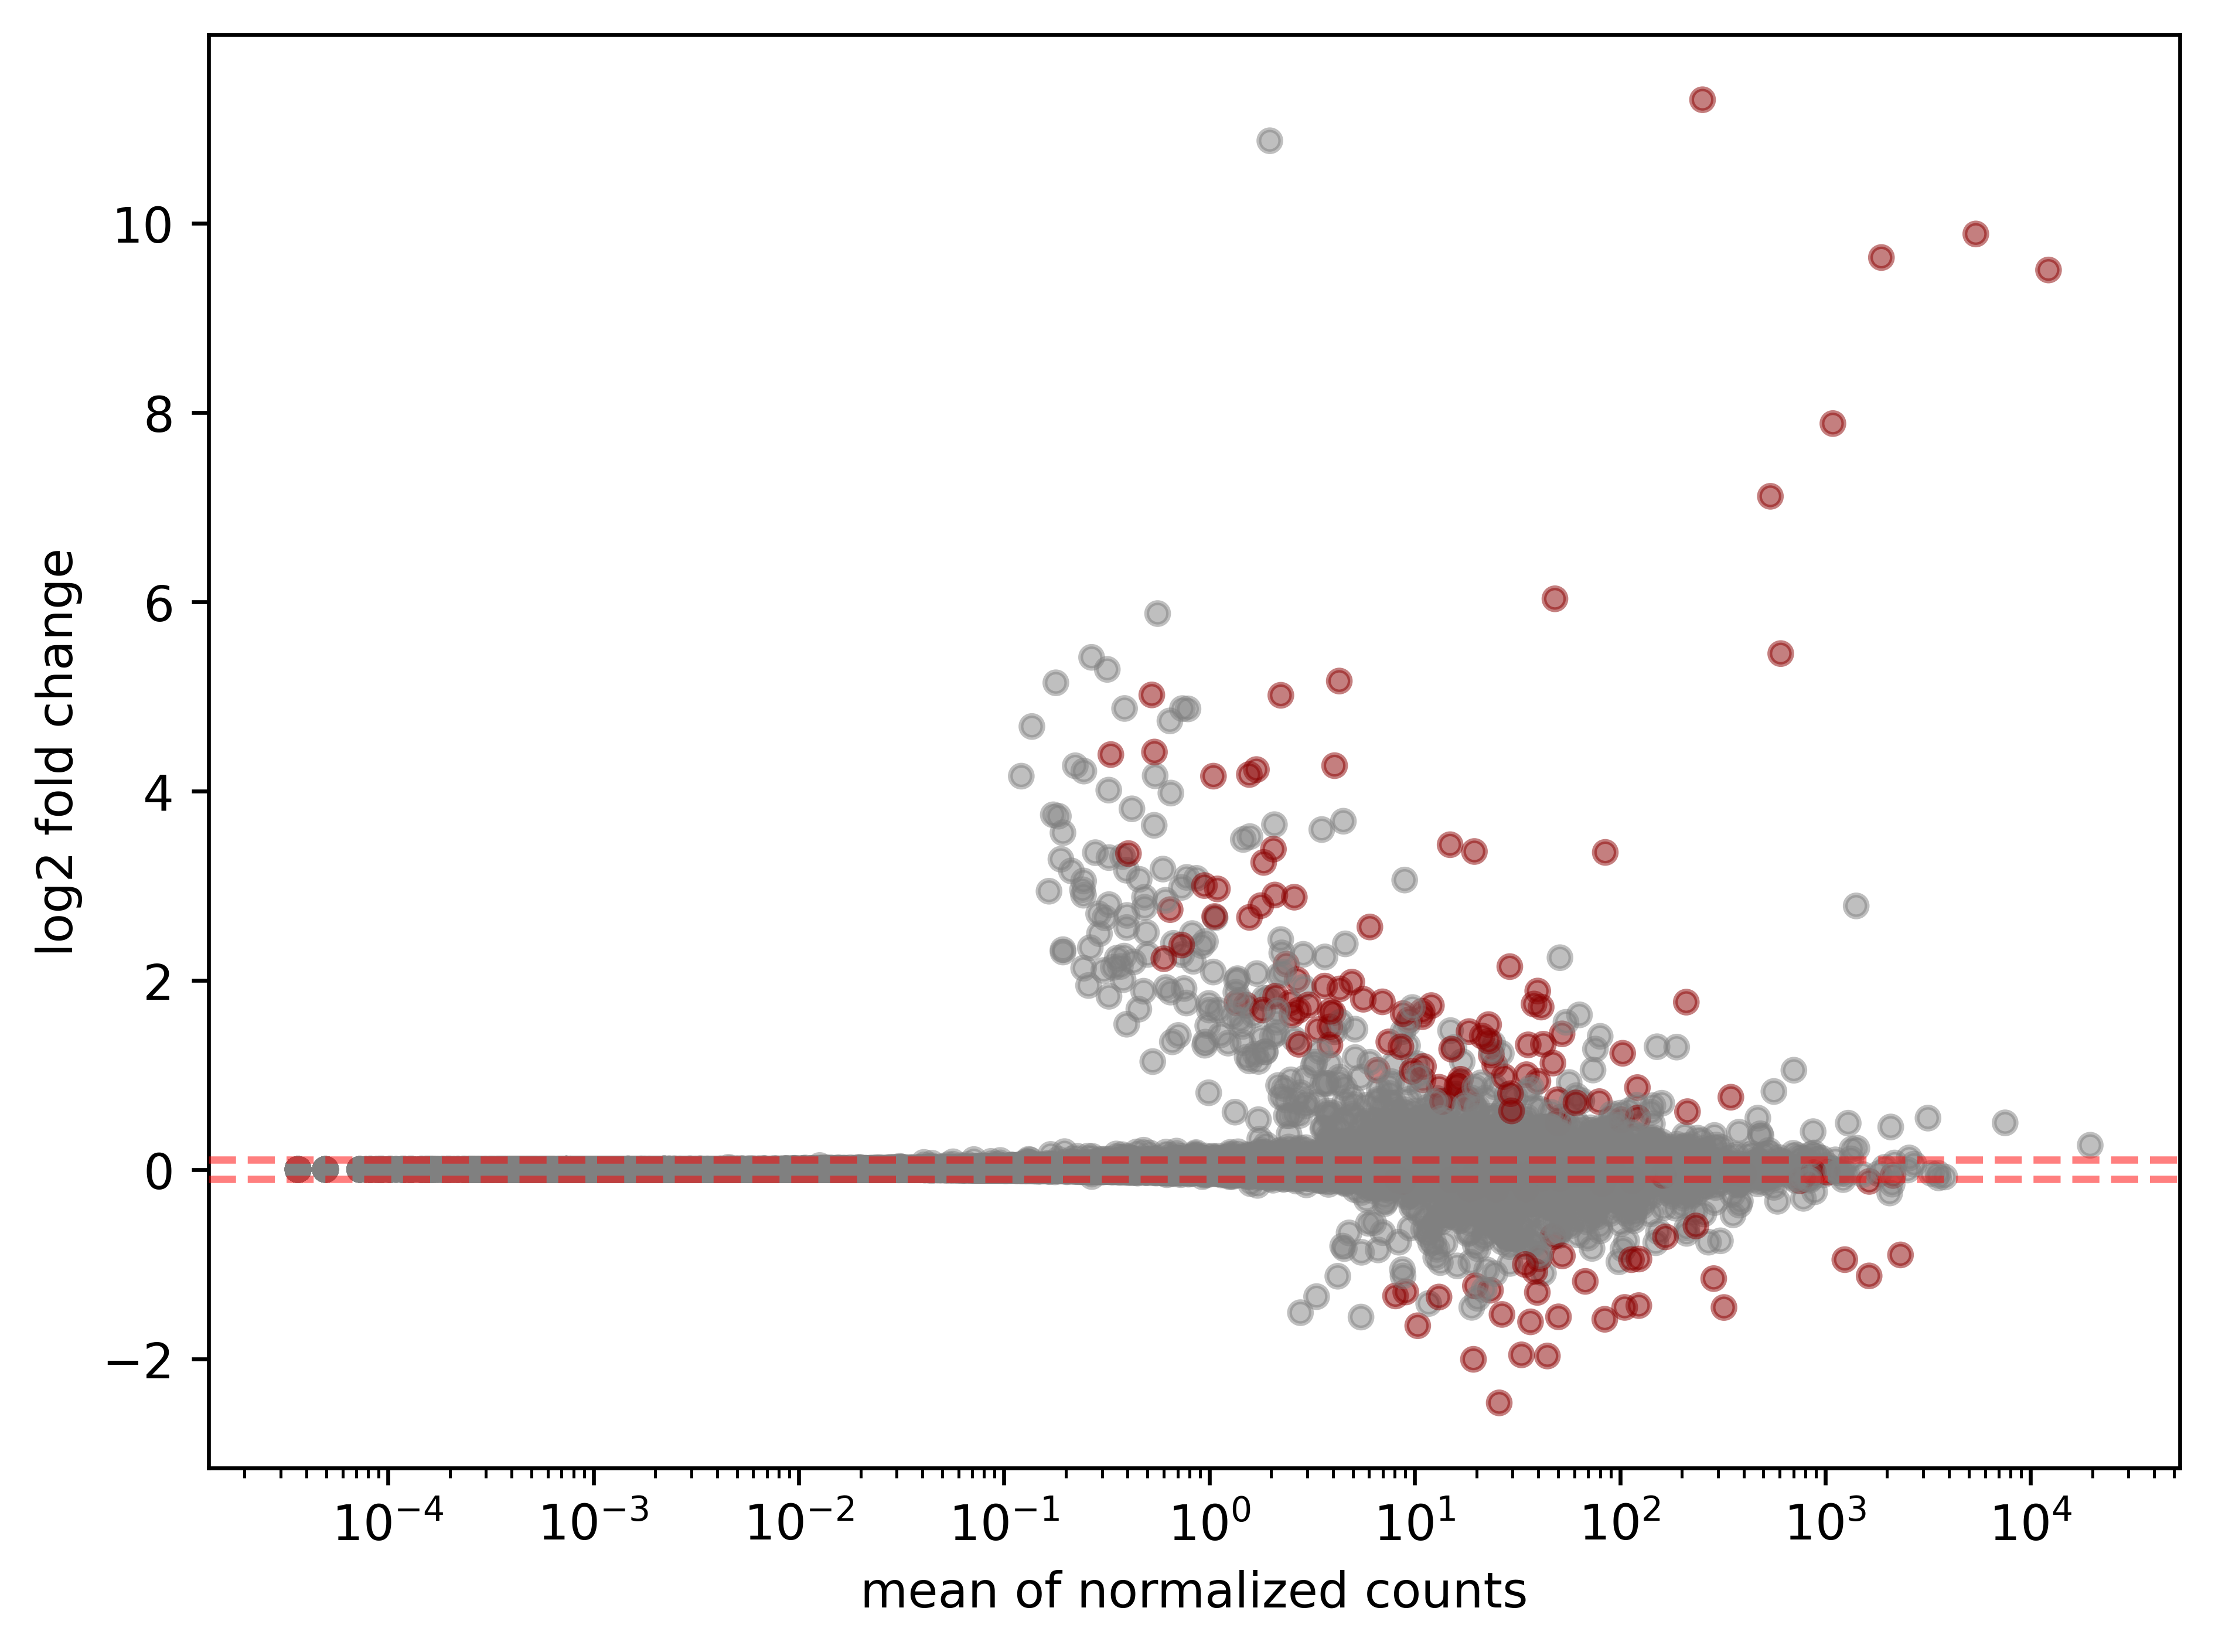

In [ ]:
ds_Paneth.plot_MA(s=20)

In [ ]:
ds_Paneth.results_df[ds_Paneth.results_df.padj < 0.05].shape

(181, 6)

In [ ]:
ds_Paneth.results_df.to_excel("Cell_Paneth.results.xlsx")

# EECs

In [ ]:
design_EEC = FormulaicContrasts(
    myMetaDats, '~ C(Cell_EEC, contr.treatment(base="rest"))'
).design_matrix

In [ ]:
design_EEC.head()

,Intercept,"C(Cell_EEC, contr.treatment(base='rest'))[T.EECs]"
A26 (386C)_BEST2+ Goblet cell,1.0,0
A30 (398B)_BEST2+ Goblet cell,1.0,0
A32 (411C)_BEST2+ Goblet cell,1.0,0
A33 (414C)_BEST2+ Goblet cell,1.0,0
A34 (417C)_BEST2+ Goblet cell,1.0,0


In [ ]:
design_EEC.columns = ['Intercept','condition[T.EECs]']

In [ ]:
design_EEC.head()

,Intercept,condition[T.EECs]
A26 (386C)_BEST2+ Goblet cell,1.0,0
A30 (398B)_BEST2+ Goblet cell,1.0,0
A32 (411C)_BEST2+ Goblet cell,1.0,0
A33 (414C)_BEST2+ Goblet cell,1.0,0
A34 (417C)_BEST2+ Goblet cell,1.0,0


In [ ]:
design_EEC['condition[T.EECs]'].value_counts()

,count
condition[T.EECs],
0,279
1,10


In [ ]:
design_EEC['Intercept'].value_counts()

,count
Intercept,
1.0,289


In [ ]:
#
# inference = DefaultInference(n_cpus=8)
#
dds_EEC = DeseqDataSet(
    counts=myCounts,
    metadata=myMetaDats,
    design= design_EEC,
    refit_cooks=True,
    inference=inference,
)

In [ ]:
dds_EEC.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.39 seconds.

Fitting dispersions...
... done in 13.42 seconds.

Fitting dispersion trend curve...
... done in 0.84 seconds.

Fitting MAP dispersions...
... done in 15.01 seconds.

Fitting LFCs...
... done in 16.60 seconds.

Calculating cook's distance...
... done in 0.82 seconds.

Replacing 603 outlier genes.

Fitting dispersions...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 0.41 seconds.

Fitting LFCs...
... done in 0.56 seconds.



In [ ]:
dds_EEC.varm['LFC'].head()

,Intercept,condition[T.EECs]
MIR1302-2HG,-1.083655,-0.240486
OR4F5,-1.113461,-0.210625
AL627309.1,-1.125186,-0.200291
AL627309.3,-1.094321,-0.229788
AL732372.1,-1.109887,-0.214199


In [ ]:
ds_EEC = DeseqStats(dds_EEC, contrast=np.array([0, 1]), inference=inference)

In [ ]:
ds_EEC.summary()

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [0 1]
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
MIR1302-2HG  0.014665       -0.346948  4.071001 -0.085224  0.932083       NaN
OR4F5        0.000091       -0.303867  8.001732 -0.037975  0.969707       NaN
AL627309.1   0.160779       -0.288959  1.110655 -0.260170  0.794733       NaN
AL627309.3   0.009303       -0.331514  5.419344 -0.061172  0.951222       NaN
AL732372.1   0.000793       -0.309023  8.001717 -0.038620  0.969194       NaN
...               ...             ...       ...       ...       ...       ...
AC233755.2   0.019028       -0.415266  4.949031 -0.083909  0.933129       NaN
AC233755.1   0.119847       -0.776260  2.666565 -0.291108  0.770968       NaN
AC240274.1   3.890857       -1.105012  0.480555 -2.299449  0.021479  0.213398
AC213203.1   0.000000             NaN       NaN       NaN       NaN       NaN
FAM231C      0.018293       -0.378658  4.828618 -0.078420  0.937494       NaN

[3

... done in 2.76 seconds.



Running Wald tests...
... done in 6.06 seconds.



Log2 fold change & Wald test p-value, contrast vector: [0 1]
             baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
MIR1302-2HG  0.014665       -0.346948  4.071001 -0.060660  0.951630   NaN
OR4F5        0.000091       -0.303867  8.001732 -0.025478  0.979674   NaN
AL627309.1   0.160779       -0.288959  1.110655 -0.170133  0.864905   NaN
AL627309.3   0.009303       -0.331514  5.419344 -0.042720  0.965925   NaN
AL732372.1   0.000793       -0.309023  8.001717 -0.026122  0.979160   NaN
...               ...             ...       ...       ...       ...   ...
AC233755.2   0.019028       -0.415266  4.949031 -0.063703  0.949207   NaN
AC233755.1   0.119847       -0.776260  2.666565 -0.253607  0.799799   NaN
AC240274.1   3.890857       -1.105012  0.480555 -2.091356  0.036496   NaN
AC213203.1   0.000000             NaN       NaN       NaN       NaN   NaN
FAM231C      0.018293       -0.378658  4.828618 -0.057710  0.953980   NaN

[30263 rows x 6 columns]


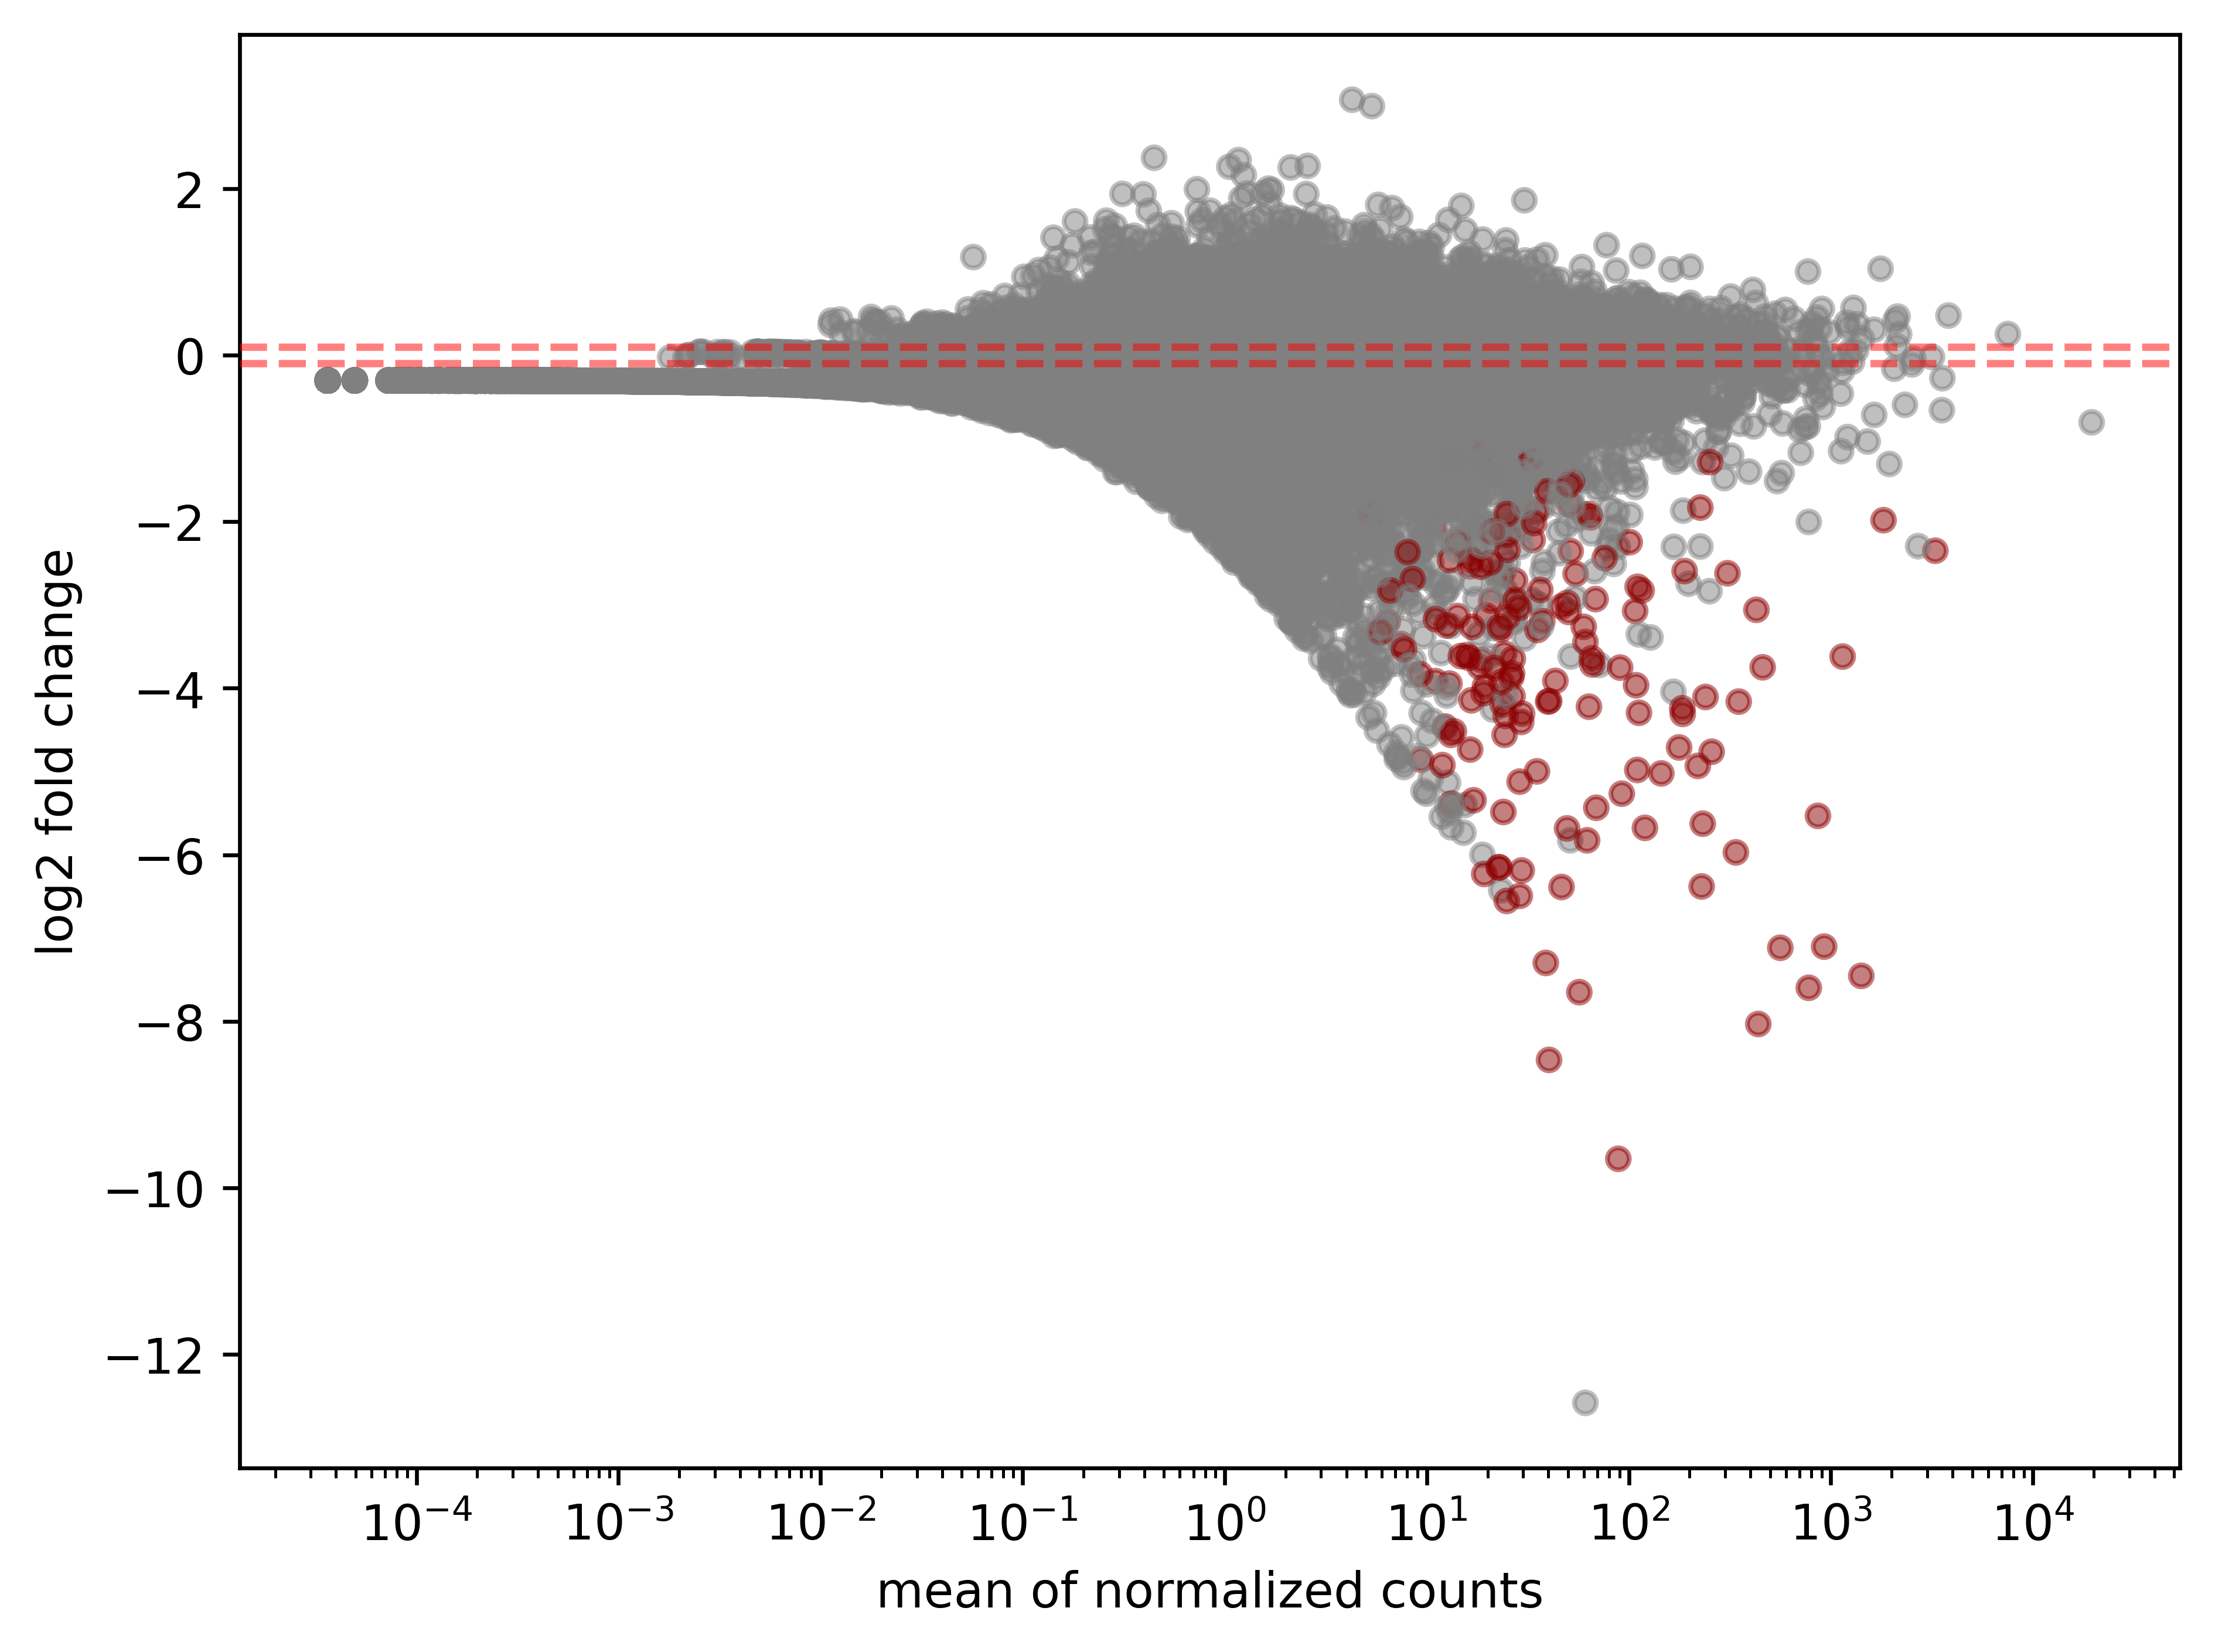

In [ ]:
ds_EEC.summary(lfc_null=0.1, alt_hypothesis="greaterAbs")
ds_EEC.plot_MA(s=20)

In [ ]:
ds_EEC.lfc_shrink(coeff="condition[T.EECs]")

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: condition[T.EECs]
             baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
MIR1302-2HG  0.014665       -0.000661  0.124940 -0.060660  0.951630   NaN
OR4F5        0.000091       -0.000035  0.125558 -0.025478  0.979674   NaN
AL627309.1   0.160779       -0.009508  0.124816 -0.170133  0.864905   NaN
AL627309.3   0.009303       -0.000383  0.125014 -0.042720  0.965925   NaN
AL732372.1   0.000793       -0.000111  0.125297 -0.026122  0.979160   NaN
...               ...             ...       ...       ...       ...   ...
AC233755.2   0.019028       -0.000638  0.124503 -0.063703  0.949207   NaN
AC233755.1   0.119847       -0.003060  0.124209 -0.253607  0.799799   NaN
AC240274.1   3.890857       -0.088281  0.170088 -2.091356  0.036496   NaN
AC213203.1   0.000000             NaN       NaN       NaN       NaN   NaN
FAM231C      0.018293       -0.000614  0.124715 -0.057710  0.953980   NaN

[30263 rows x 6 columns]


... done in 13.48 seconds.



In [ ]:
print(ds_EEC.shrunk_LFCs)

True


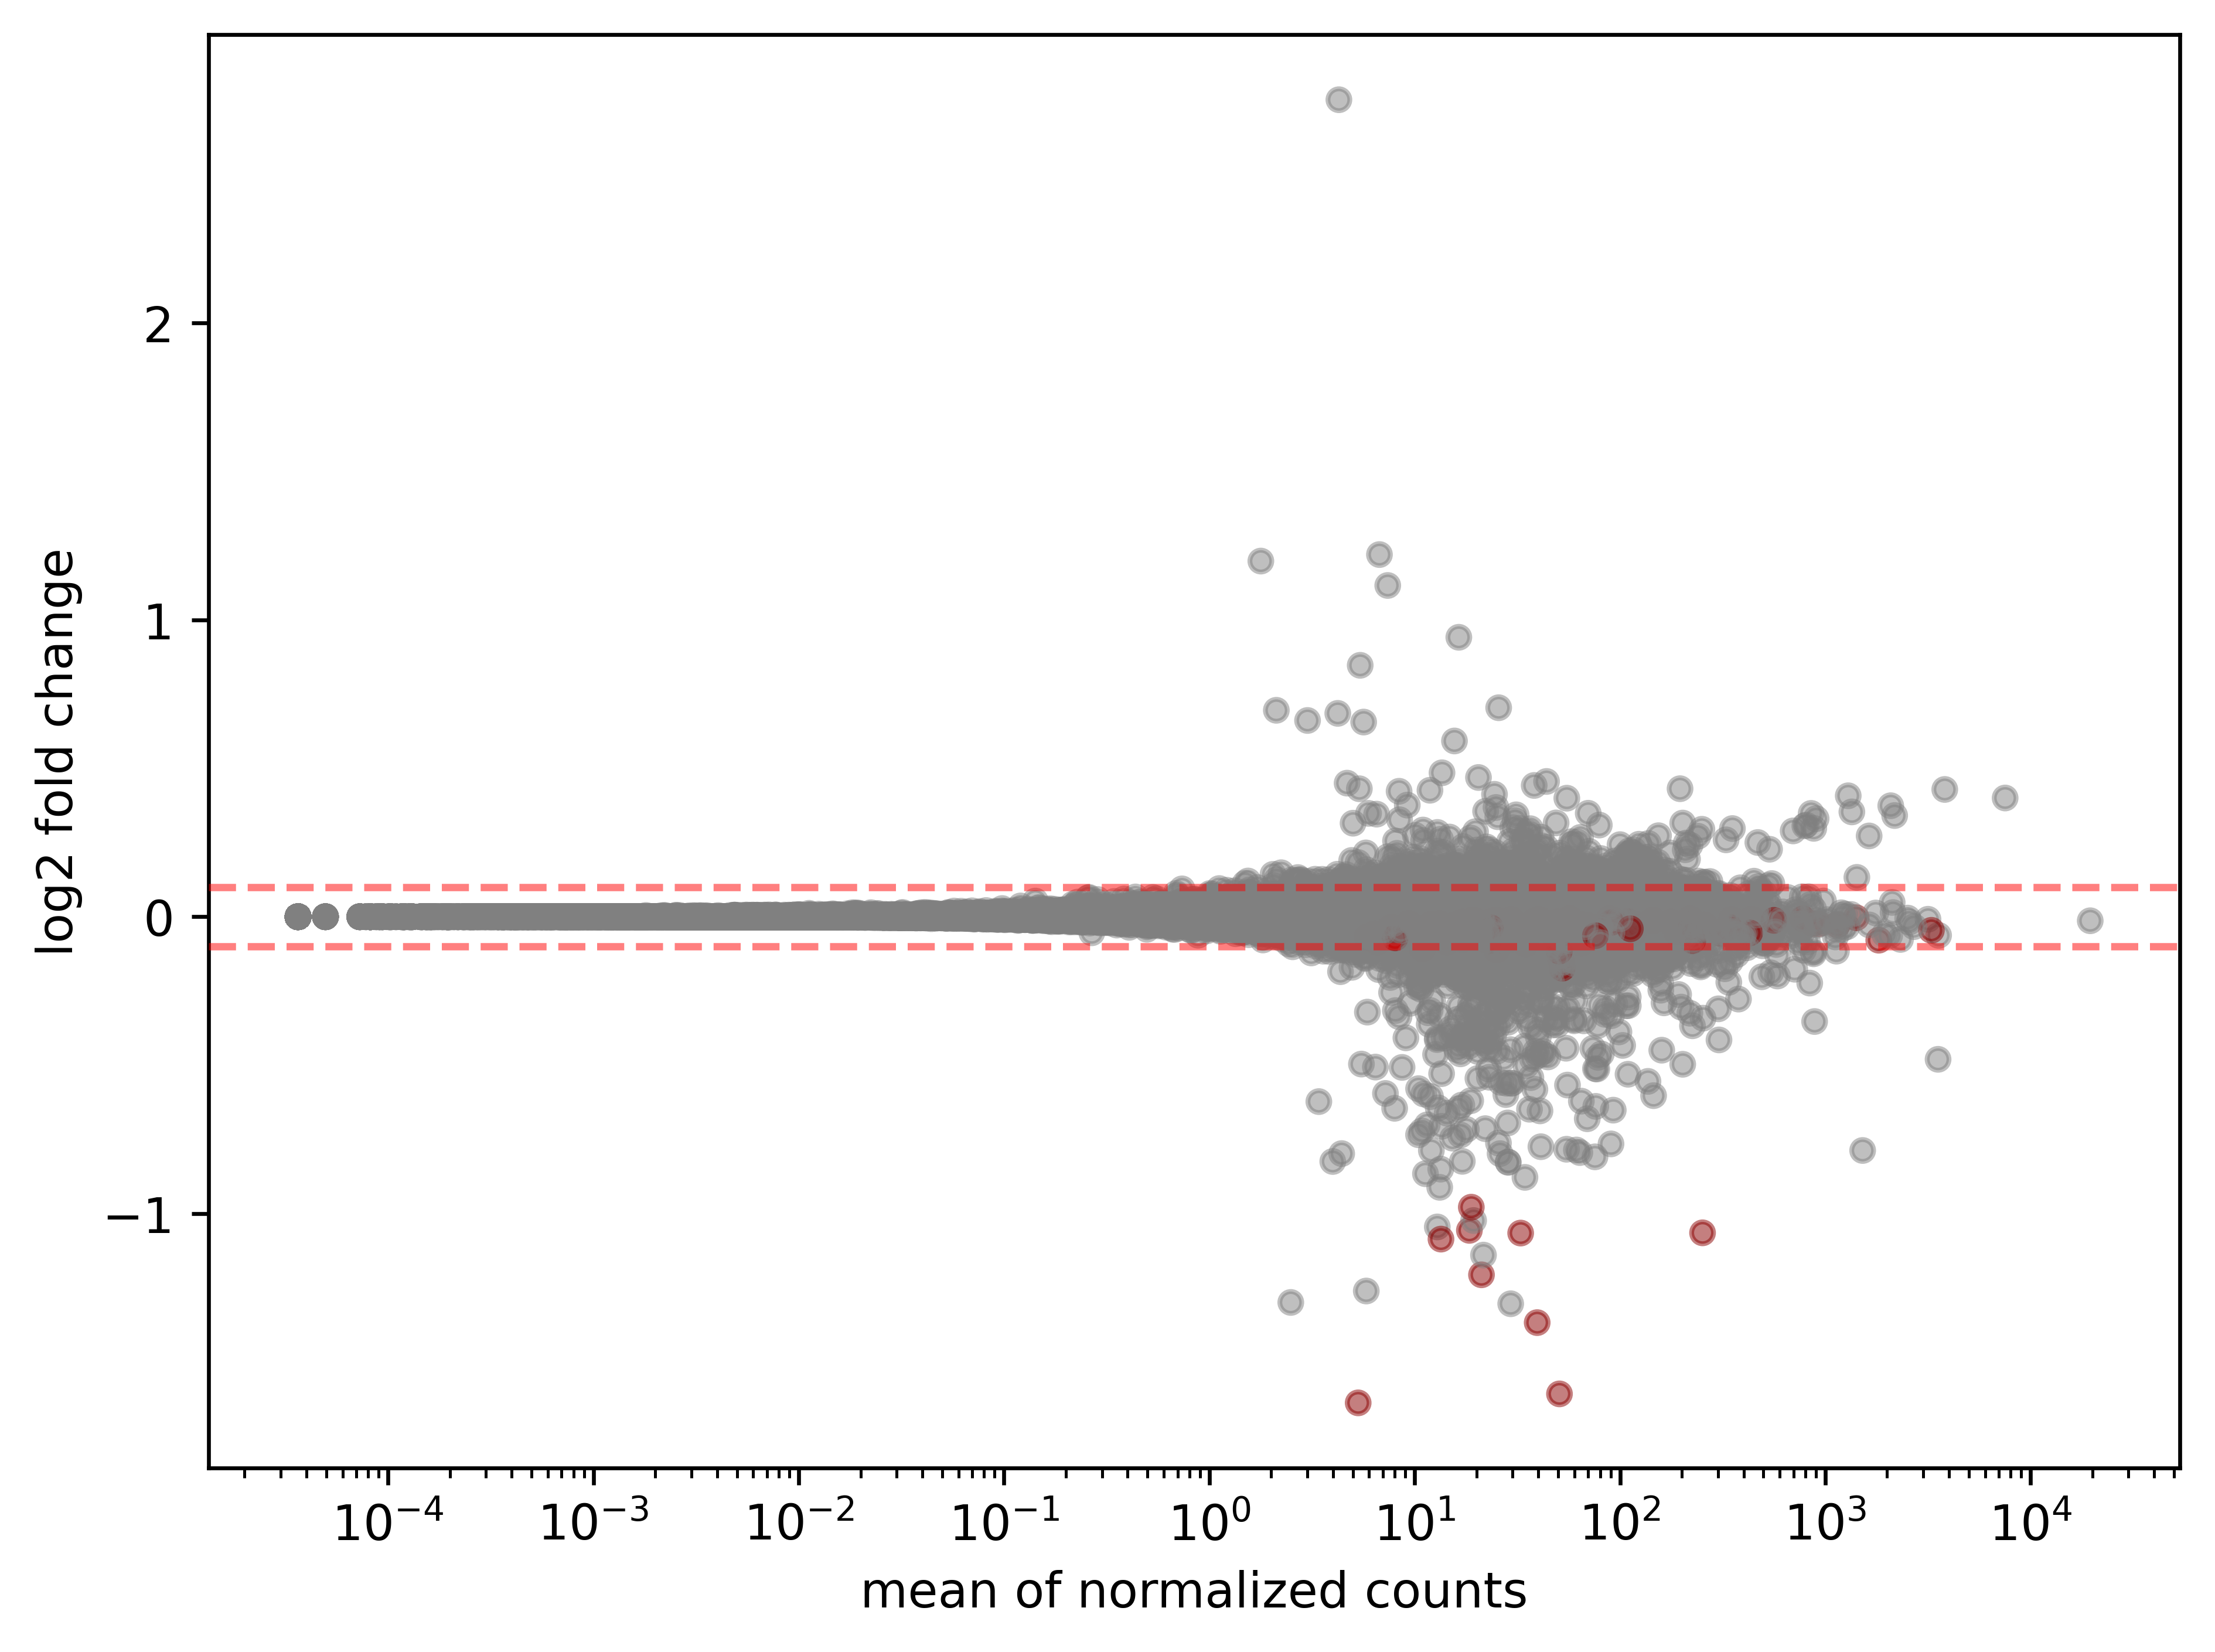

In [ ]:
ds_EEC.plot_MA(s=20)

In [ ]:
ds_EEC.results_df[ds_EEC.results_df.padj < 0.05].shape

(150, 6)

In [ ]:
ds_EEC.results_df.to_excel("Cell_EEC.results.xlsx")

# Session info

In [ ]:
%watermark -u -n -t -z -m --iversions --jupyter_env

Last updated: Mon, 13 Apr 2026 22:53:36 UTC

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.113+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 8
Architecture: 64bit

decoupler          : 2.1.6
formulaic_contrasts: 1.0.0
google             : 3.0.0
matplotlib         : 3.10.0
numpy              : 2.0.2
pandas             : 2.3.3
pydeseq2           : 0.5.4
scanpy             : 1.12.1
scipy              : 1.16.3

Jupyter enviroment: Google Colab

